In [1]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.getOrCreate()

In [2]:
def readMariaDB(table_name, database):
    dfMaria = spark.read \
            .format("jdbc") \
            .option("driver", "org.mariadb.jdbc.Driver") \
            .option("url", f"jdbc:mysql://localhost:3306/{database}?permitMysqlScheme") \
            .option("dbtable", f"{table_name}") \
            .option("user", "root") \
            .option("password", "Thanhdan@123") \
            .load()

    return dfMaria

# Exercise 1
Get all the number of users created per year.
* Use the users table for this exercise.
* The output should contain a 4-digit year and count.
* Use date-specific functions to get the year using created_ts.
* Make sure you define aliases to the columns as created_year and user_count, respectively.
* Data should be sorted in ascending order by created_year
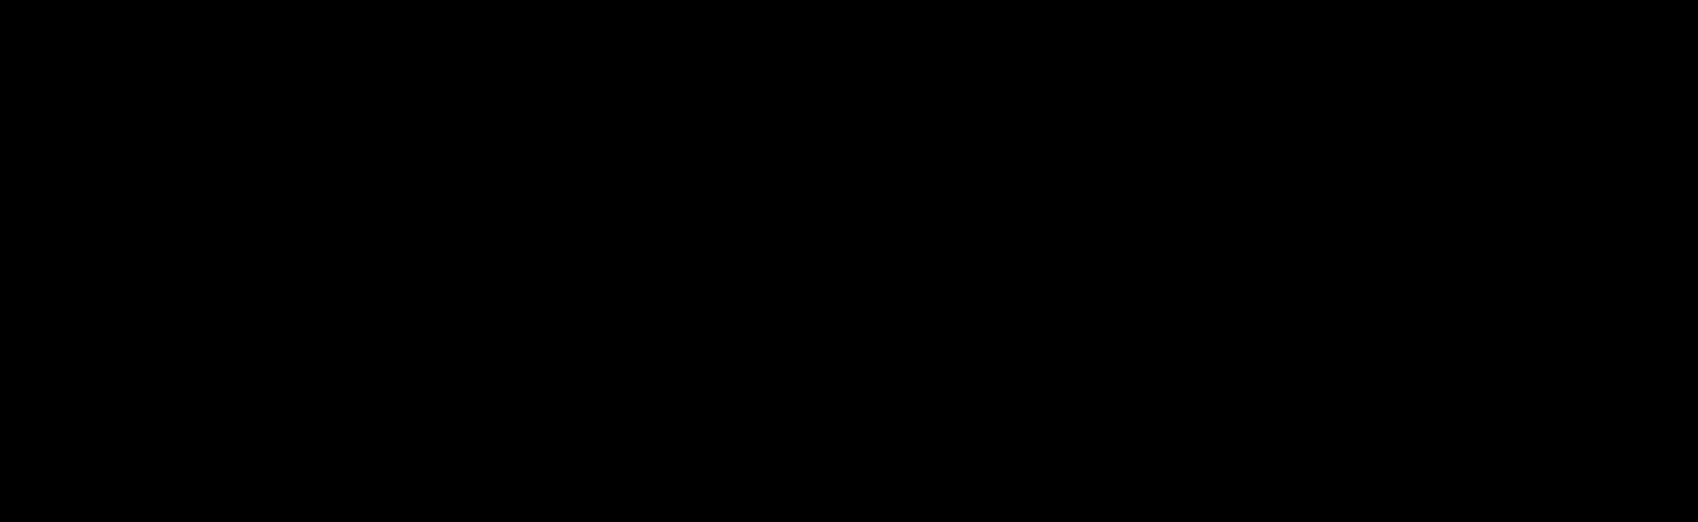
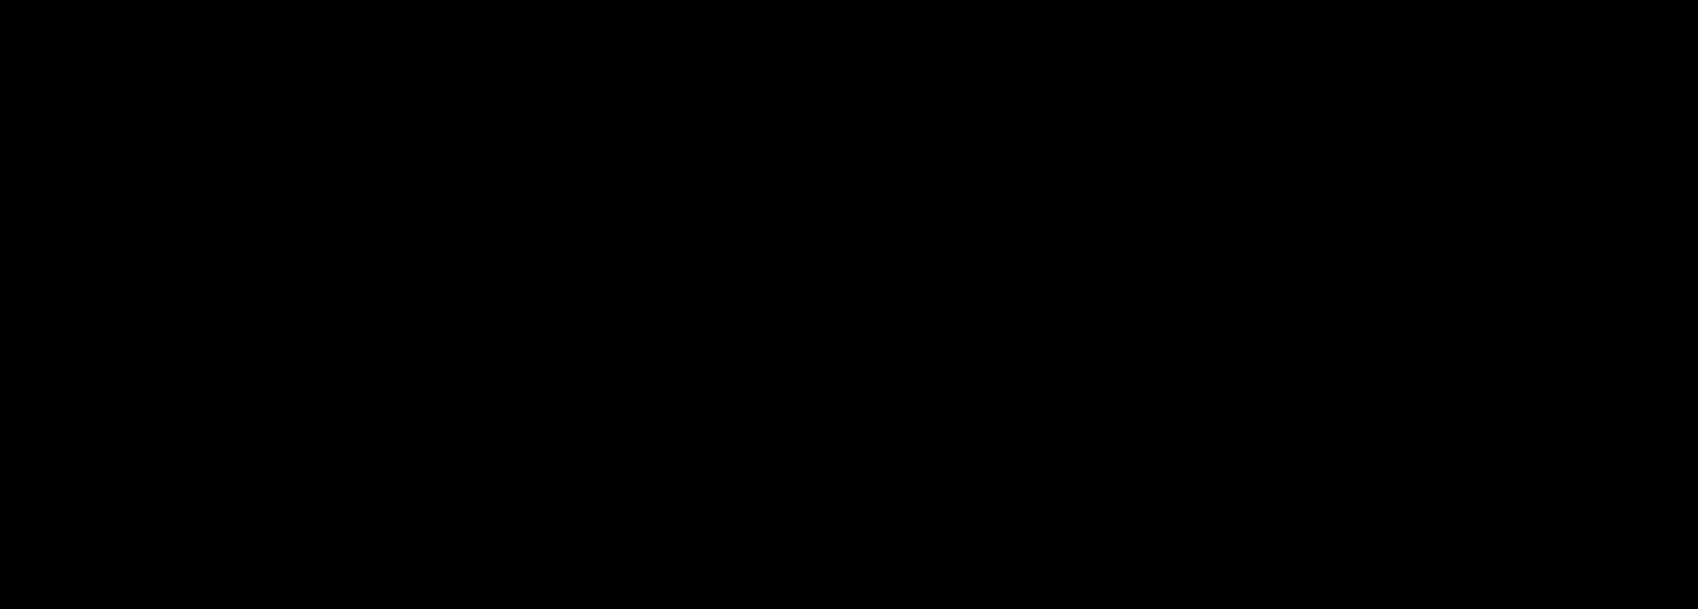

In [3]:
users_df = readMariaDB("users", "retails")
users_df.createOrReplaceTempView("users")

In [4]:
spark.sql("""
select
    year(created_ts) as created_year,
    count(user_id) as user_count
from users
group by created_year
order by created_year asc;
""").show()

+------------+----------+
|created_year|user_count|
+------------+----------+
|        2018|        13|
|        2019|         4|
|        2020|         8|
+------------+----------+



# Exercise 2
Get the day name of the birth days for all the users born in the month of June.
* Use the users table for this exercise.
* Output should contain user_id, user_dob, user_email_id and user_day_of_birth.
* Use date-specific functions to get the month using user_dob.
* user_day_of_birth should be a full day with the first character in upper case, such as Tuesday
* Data should be sorted by day within the month of May

In [5]:
spark.sql("""
select
    user_id,
    user_dob,
    user_email_id,
    dayname(user_dob) as user_day_of_birth
from users
where month(user_dob) = 5
order by day(user_dob)
""").show()

+-------+----------+--------------------+-----------------+
|user_id|  user_dob|       user_email_id|user_day_of_birth|
+-------+----------+--------------------+-----------------+
|      4|1998-05-24|mtanswill3@dedecm...|              Sun|
|     12|1983-05-26|uglayzerb@pintere...|              Thu|
|      1|1973-05-31|    gbode0@imgur.com|              Thu|
|      2|2003-05-31|    lgisbey1@mail.ru|              Sat|
+-------+----------+--------------------+-----------------+



# Exercise 3
Get the names and email IDs of users added in the year 2019.
* Use the users table for this exercise.
* Output should contain user_id, user_name, user_email_id, created_ts, created_year.
* Use date-specific functions to get the year using created_ts.
* user_name is a derived column by concatenating user_first_name and user_last_name with a space in between.
* user_name should have values in uppercase.
* Data should be sorted in ascending order by user_name

In [6]:
spark.sql("""
select
    user_id,
    upper(concat(user_first_name,' ',user_last_name)) as user_name,
    user_email_id,
    created_ts,
    year(created_ts) as created_year
from users
where year(created_ts) = 2019
order by user_name
""").show()

+-------+---------------+--------------------+-------------------+------------+
|user_id|      user_name|       user_email_id|         created_ts|created_year|
+-------+---------------+--------------------+-------------------+------------+
|      8|CYBIL LISSIMORE|clissimore7@pinte...|2019-12-09 14:08:30|        2019|
|     25|   PHYLYS ASLIE|      paslieo@qq.com|2019-10-01 01:34:28|        2019|
|     12|    UNA GLAYZER|uglayzerb@pintere...|2019-09-17 03:24:21|        2019|
|     17|    YANKEE JELF|    yjelfg@wufoo.com|2019-09-16 16:09:12|        2019|
+-------+---------------+--------------------+-------------------+------------+



# Exercise 4
Get the number of users by gender.
* Use the users table for this exercise.
* Output should contain gender and user_count.
* For males, the output should display Male, and for females, the output should display Female.
* If gender is not specified, then it should display Not Specified.
* Data should be sorted in descending order by user_count.
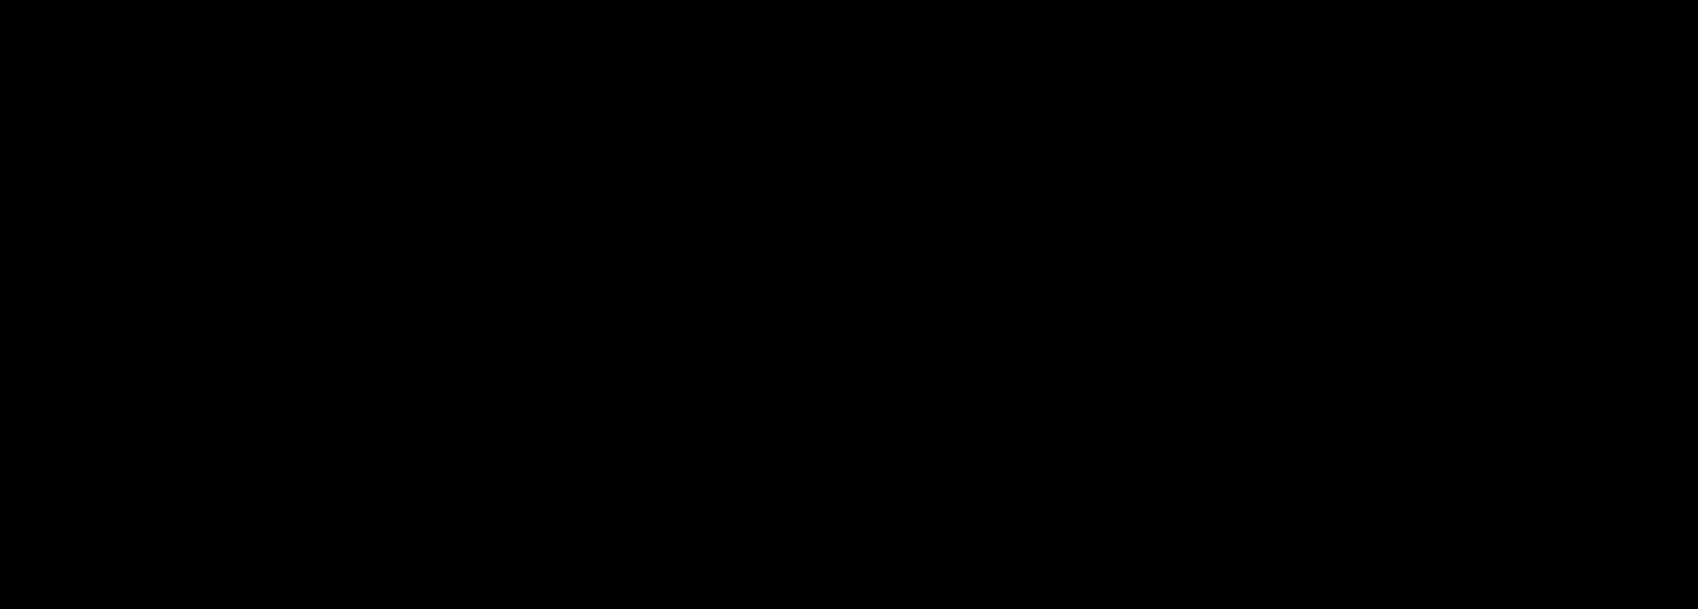

In [7]:
spark.sql("""
select distinct
    case
        when user_gender = 'M' then 'Male'
        when user_gender = 'F' then 'Female'
        else 'Not Specified' end as user_gender,
    count(*) over (partition by user_gender) as user_count
from users
order by user_count desc
""").show()

+-------------+----------+
|  user_gender|user_count|
+-------------+----------+
|       Female|        13|
|         Male|        10|
|Not Specified|         2|
+-------------+----------+



# Exercise 5
Get the last 4 digits of unique IDs.
* Use the users table for this exercise.
* Output should contain user_id, user_unique_id and user_unique_id_last4
* Unique IDs are either null or not null.
* Unique IDs contain numbers and hyphens and are of different lengths.
* We need to get the last 4 digits, discarding hyphens only when the number of digits is at least 9.
* If the unique ID is null, then you should display Not Specified.
* After discarding hyphens, if the unique ID has fewer than 9 digits, then you should display Invalid Unique ID.
* Data should be sorted by user_id. You might see None or null for those user IDs where there is no unique ID for the user_unique_id

In [8]:
spark.sql("""
select
    user_id,
    user_unique_id,
    case
        when length(replace(user_unique_id,'-','')) >= 9 then right(replace(user_unique_id,'-',''),4)
        when length(replace(user_unique_id,'-','')) < 9 then 'Invalid Unique Id'
        else 'Not Specified' end as user_unique_id
from users
order by user_id
""").show()

+-------+--------------+--------------+
|user_id|user_unique_id|user_unique_id|
+-------+--------------+--------------+
|      1|    88833-8759|          8759|
|      2|    262501-029|          1029|
|      3|    391-332823|          2823|
|      4|    1195413-80|          1380|
|      5|   471-24-6869|          6869|
|      6|    192374-933|          4933|
|      7|   749-27-4752|          4752|
|      8|    461-754198|          4198|
|      9|   892-36-6762|          6762|
|     10|   197-54-1646|          1646|
|     11|   232-5552-58|          5258|
|     12|  898-84-336-6|          3366|
|     13|  247-95-68-44|          6844|
|     14|  415-48-894-3|          8943|
|     15|   40339-5-869|          5869|
|     16|  399-83-05-03|          0503|
|     17|   607-99-0411|          0411|
|     18|  430-01-578-5|          5785|
|     19|    571-096181|          6181|
|     20|  478-32-02-87|          0287|
+-------+--------------+--------------+
only showing top 20 rows


# Exercise 6
Get the count of users based on country code.
* Use the users table for this exercise.
* Output should contain the country code and count.
* There should be no + in the country code. It should only contain digits.
* Data should be sorted as numbers by country code.
* We should discard user_phone_no with null values.

In [11]:
spark.sql("""
select
    left(replace(user_phone_no,'+',''), locate(' ',user_phone_no) - 2) as country_code,
    count(*) as user_count
from users
where user_phone_no is not null
group by country_code
order by cast(country_code as double)
""").show()

+------------+----------+
|country_code|user_count|
+------------+----------+
|           1|         1|
|           7|         2|
|          48|         1|
|          54|         1|
|          55|         1|
|          62|         3|
|          63|         1|
|          81|         1|
|          84|         1|
|          86|         4|
|         229|         1|
|         249|         1|
|         351|         1|
|         370|         1|
|         380|         1|
|         420|         1|
|         598|         1|
+------------+----------+



# Exercise 7
Let us validate if we have an invalid order_item_subtotal as part of the order_items table.
* The order_items table has 6 fields.
* order_item_id
* order_item_order_id
* order_item_product_id
* order_item_quantity
* order_item_subtotal
* order_item_product_price
* order_item_subtotal is nothing but the product of order_item_quantity and order_item_product_price. It means order_item_subtotal is computed by multiplying order_item_quantity and order_item_product_price for each item.
* You need to get the count of order_items where order_item_subtotal is not equal to the
product of order_item_quantity and order_item_product_price.
* There can be issues related to rounding off. Make sure it is taken care of using the
appropriate function.

The output should be 0 as there are no such records.

In [12]:
df = readMariaDB("order_items", "retails")
df.createOrReplaceTempView("order_items")

In [13]:
spark.sql("""
    select count(*) as invalid_count
    from order_items
    where round(order_item_subtotal, 2) != round(cast(order_item_quantity as float) * order_item_product_price, 2)
""").show()

+-------------+
|invalid_count|
+-------------+
|            0|
+-------------+



# Exercise 8
Get the number of orders placed on weekdays and weekends in the month of January 2014.
* Orders have 4 fields: order_id, order_date, order_customer_id, order_status
* Use the order date to determine the day on which orders are placed.
* Output should contain 2 columns - day_type and order_count.
* day_type should have 2 values: Week days and Weekend days.

Here is the desired output.

In [14]:
df1 = readMariaDB("orders", "retails")
df1.printSchema()

root
 |-- order_id: integer (nullable = true)
 |-- order_date: timestamp (nullable = true)
 |-- order_customer_id: integer (nullable = true)
 |-- order_status: string (nullable = true)



In [15]:
df1.createOrReplaceTempView("orders")

In [16]:
spark.sql("""
    select
        case
            when weekday(order_date) >= 5 then 'Weekend days'
            else 'Week days' end as day_type,
        count(*) as order_count
    from orders
    group by day_type
""").show()

+------------+-----------+
|    day_type|order_count|
+------------+-----------+
|Weekend days|      19719|
|   Week days|      49164|
+------------+-----------+

